# Gradient Descent — Synthetic Functions and Linear Regression

This notebook explores gradient descent optimisation from first principles using `mlpackage`'s
`GradientDescent1D` and `GradientDescentND` classes.

- **Part 1:** 1-D gradient descent on a polynomial with multiple local minima; effect of learning rate
- **Part 2:** N-D gradient descent on a 2-D quadratic bowl; contour plot of the optimisation path
- **Part 3:** Manual linear regression via gradient descent on a single feature from the CCPP dataset,
  compared against the closed-form OLS solution

## Mathematical Intuition

### The Gradient and Update Rule

For a differentiable loss $L(\mathbf{w})$, the gradient $\nabla L(\mathbf{w})$ points in the
direction of steepest ascent. Gradient descent moves in the opposite direction:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \, \nabla L(\mathbf{w})$$

where $\eta > 0$ is the **learning rate** (step size).

### Effect of Learning Rate

| $\eta$ too small | $\eta$ appropriate | $\eta$ too large |
|---|---|---|
| Convergence is very slow | Steady decrease toward minimum | Loss oscillates or diverges |

Formally, for a quadratic $L(w) = aw^2$, the update is $w_{t+1} = (1 - 2a\eta)w_t$.
Convergence requires $|1 - 2a\eta| < 1$, i.e. $\eta < 1/a$.

### 1-D Case

Given $f: \mathbb{R} \to \mathbb{R}$ and its derivative $f'$, the algorithm tracks a scalar $x$:

$$x_{t+1} = x_t - \eta \, f'(x_t)$$

The trajectory $\{(x_t,\, f(x_t))\}$ traces the path down (or across) the function landscape.

### N-D Case

For $\mathbf{w} \in \mathbb{R}^d$, the gradient is a vector of partial derivatives. The same
scalar update rule extends component-wise.

### Linear Regression via Gradient Descent

For $L(\mathbf{w}) = \frac{1}{n}\|\mathbf{y} - X\mathbf{w}\|^2$, the gradient is:

$$\nabla L(\mathbf{w}) = -\frac{2}{n} X^\top (\mathbf{y} - X\mathbf{w})$$

Setting this to zero gives the OLS normal equations $\mathbf{w}^* = (X^\top X)^{-1} X^\top \mathbf{y}$,
which gradient descent approximates iteratively without requiring a matrix inverse.

## Imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from mlpackage import GradientDescent1D, GradientDescentND, LinearRegression, StandardScaler, train_test_split

## Part 1 — GradientDescent1D

We minimise $f(x) = x^4 - 4x^3 + 4x$, which has a local minimum near $x \approx 0.4$ and a
deeper minimum near $x \approx 3$. Starting from $x_0 = 3.0$.

In [11]:
f  = lambda x: x**4 - 4*x**3 + 4*x
df = lambda x: 4*x**3 - 12*x**2 + 4

optimizer = GradientDescent1D(learning_rate=0.01, n_iterations=500)
optimal_x, history = optimizer.optimize(f, df, w_init=3.0)

xs_hist = [h[0] for h in history]
fs_hist = [h[1] for h in history]

print(f"Optimal x : {optimal_x:.6f}")
print(f"f(x*)     : {f(optimal_x):.6f}")

Optimal x : 2.879385
f(x*)     : -15.234422


/var/folders/xn/8psq9j452vb5j53pr4839sth0000gn/T/ipykernel_6860/2177167607.py:22: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()


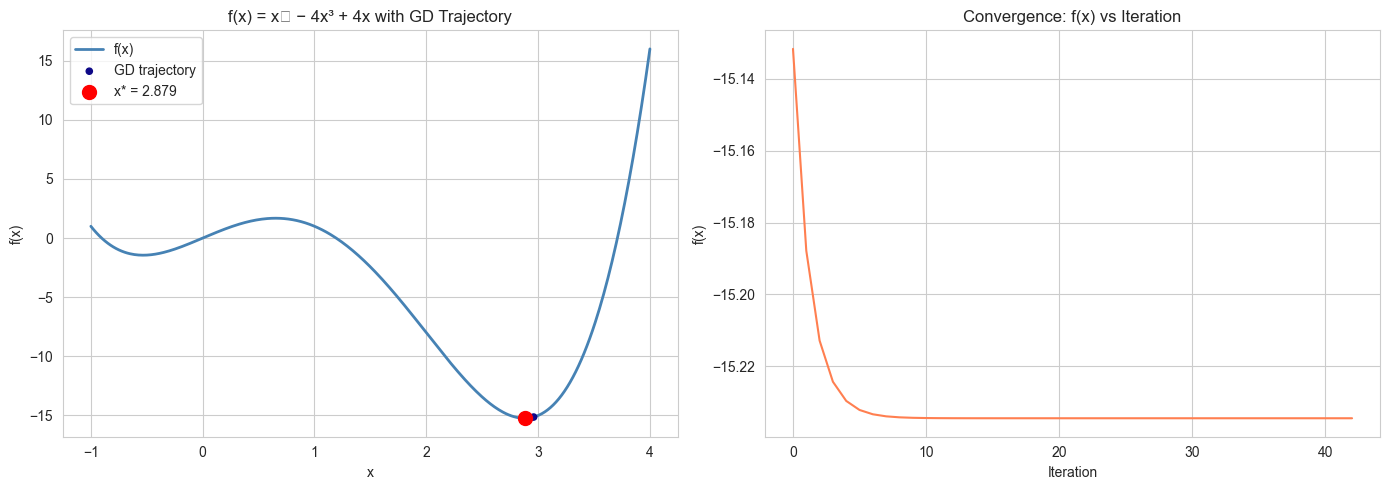

In [12]:
# Function curve + optimisation trajectory
x_plot = np.linspace(-1, 4, 400)
y_plot = f(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_plot, y_plot, color="steelblue", linewidth=2, label="f(x)")
axes[0].scatter(xs_hist, fs_hist, c=np.arange(len(xs_hist)), cmap="plasma",
                s=20, zorder=5, label="GD trajectory")
axes[0].plot(xs_hist, fs_hist, ":", color="gray", linewidth=0.8)
axes[0].scatter([optimal_x], [f(optimal_x)], color="red", s=100, zorder=6, label=f"x* = {optimal_x:.3f}")
axes[0].set_title("f(x) = x⁴ − 4x³ + 4x with GD Trajectory")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()

axes[1].plot(fs_hist, color="coral")
axes[1].set_title("Convergence: f(x) vs Iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("f(x)")

plt.tight_layout()
plt.show()

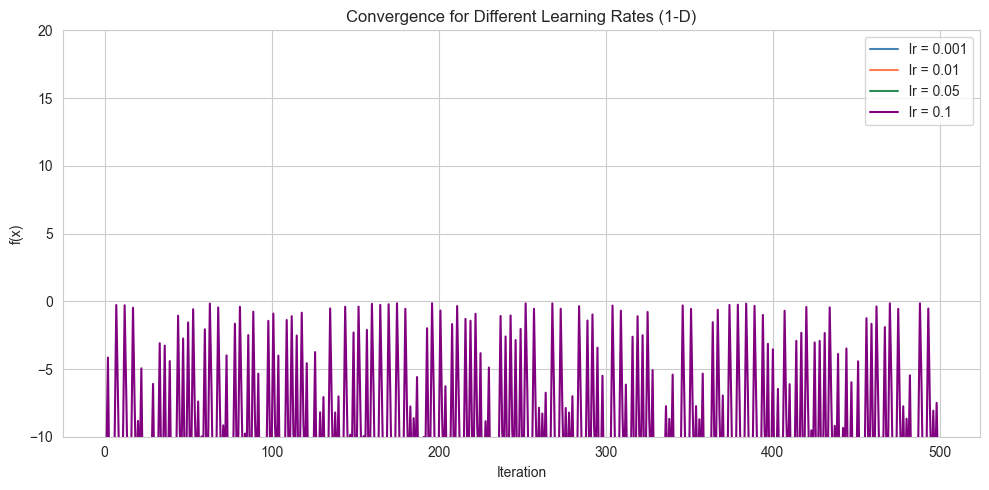

In [13]:
# Effect of learning rate
learning_rates = [0.001, 0.01, 0.05, 0.1]
colors = ["steelblue", "coral", "seagreen", "purple"]

plt.figure(figsize=(10, 5))
for lr, color in zip(learning_rates, colors):
    _, hist = GradientDescent1D(learning_rate=lr, n_iterations=500).optimize(f, df, w_init=3.0)
    plt.plot([h[1] for h in hist], color=color, label=f"lr = {lr}")

plt.title("Convergence for Different Learning Rates (1-D)")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.ylim(-10, 20)
plt.legend()
plt.tight_layout()
plt.show()

## Part 2 — GradientDescentND (2-D Bowl)

Loss surface: $L(\mathbf{w}) = w_0^2 + 5w_1^2$, which is an elliptical bowl elongated along the
$w_1$ axis. Gradient: $\nabla L = [2w_0,\; 10w_1]^\top$. Minimum is at the origin.

In [14]:
grad_fn = lambda w: np.array([2*w[0], 10*w[1]])
loss_fn = lambda w: w[0]**2 + 5*w[1]**2

optimizer_nd = GradientDescentND(learning_rate=0.1, n_iterations=100)
optimal_w, loss_history = optimizer_nd.optimize(
    grad_fn, w_init=np.array([4.0, 3.0]), loss_fn=loss_fn
)

print(f"Optimal w : {optimal_w}")
print(f"L(w*)     : {loss_fn(optimal_w):.8f}")

Optimal w : [3.36999333e-07 0.00000000e+00]
L(w*)     : 0.00000000


/var/folders/xn/8psq9j452vb5j53pr4839sth0000gn/T/ipykernel_6860/509508946.py:32: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/xn/8psq9j452vb5j53pr4839sth0000gn/T/ipykernel_6860/509508946.py:32: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()


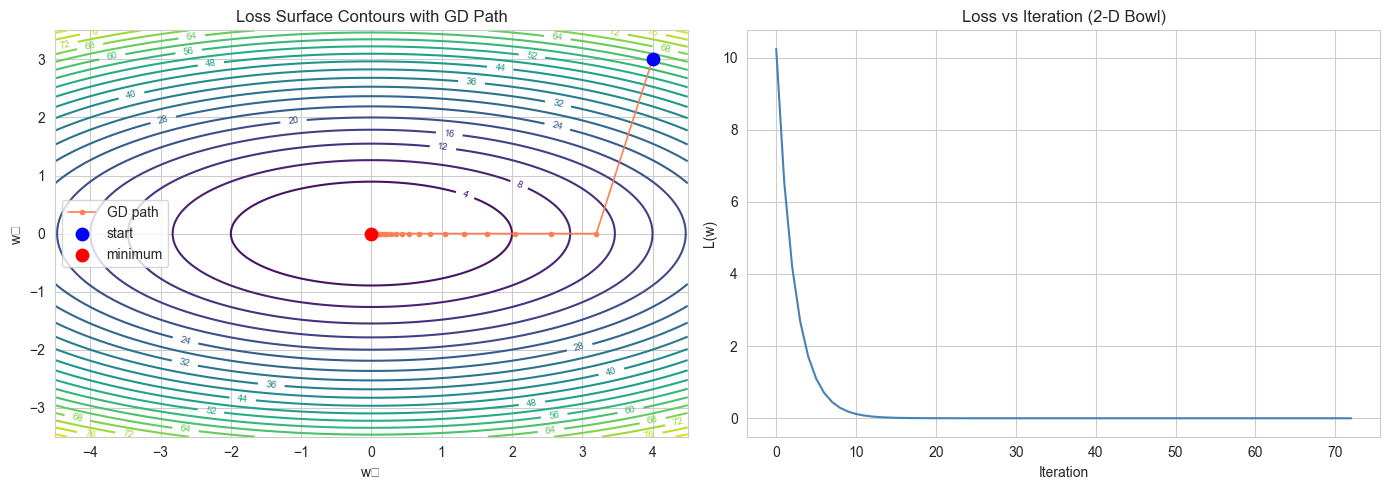

In [15]:
# Contour plot with optimisation path
w0_range = np.linspace(-4.5, 4.5, 200)
w1_range = np.linspace(-3.5, 3.5, 200)
W0, W1   = np.meshgrid(w0_range, w1_range)
Z        = W0**2 + 5*W1**2

# Reconstruct path by re-running to collect w at each step
path = [np.array([4.0, 3.0])]
w_cur = np.array([4.0, 3.0])
lr = 0.1
for _ in range(99):
    w_cur = w_cur - lr * grad_fn(w_cur)
    path.append(w_cur.copy())
path = np.array(path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cp = axes[0].contour(W0, W1, Z, levels=20, cmap="viridis")
axes[0].clabel(cp, inline=True, fontsize=7)
axes[0].plot(path[:, 0], path[:, 1], "o-", color="coral", markersize=3, linewidth=1.2, label="GD path")
axes[0].scatter([4.0], [3.0], color="blue", s=80, zorder=6, label="start")
axes[0].scatter([0.0], [0.0], color="red", s=80, zorder=6, label="minimum")
axes[0].set_title("Loss Surface Contours with GD Path")
axes[0].set_xlabel("w₀")
axes[0].set_ylabel("w₁")
axes[0].legend()

axes[1].plot(loss_history, color="steelblue")
axes[1].set_title("Loss vs Iteration (2-D Bowl)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("L(w)")
plt.tight_layout()
plt.show()

## Part 3 — Gradient Descent for Linear Regression on CCPP

We use a single feature `AT` (ambient temperature) to predict `PE` (net energy output).
We define the MSE gradient analytically and run `GradientDescentND` to find slope $w$ and
intercept $b$, then compare with the closed-form OLS solution from `LinearRegression(solver="ols")`.

In [16]:
from ucimlrepo import fetch_ucirepo

ccpp    = fetch_ucirepo(id=294)
X_ccpp  = ccpp.data.features["AT"].values.reshape(-1, 1)
y_ccpp  = ccpp.data.targets.values.ravel()

X_tr, X_te, y_tr, y_te = train_test_split(X_ccpp, y_ccpp, test_size=0.2, random_state=42)

scaler_x = StandardScaler()
X_tr_s   = scaler_x.fit_transform(X_tr)
X_te_s   = scaler_x.transform(X_te)

# Add bias column: each row is [x, 1]
X_tr_b = np.hstack([X_tr_s, np.ones((len(X_tr_s), 1))])
X_te_b = np.hstack([X_te_s, np.ones((len(X_te_s), 1))])

# MSE gradient: dL/dw = -2/n * X^T (y - X w)
def mse_grad(w):
    residuals = y_tr - X_tr_b @ w
    return -2.0 / len(y_tr) * (X_tr_b.T @ residuals)

def mse_loss(w):
    return float(np.mean((y_tr - X_tr_b @ w)**2))

gd_nd = GradientDescentND(learning_rate=0.1, n_iterations=1000)
w_gd, loss_hist_lr = gd_nd.optimize(mse_grad, w_init=np.array([0.0, 0.0]), loss_fn=mse_loss)

print(f"GD   slope={w_gd[0]:.4f}  intercept={w_gd[1]:.4f}")

GD   slope=-16.1688  intercept=454.2477


OLS  slope=-16.1688  intercept=454.2477

GD  Train R² = 0.8974  |  OLS Train R² = 0.8974


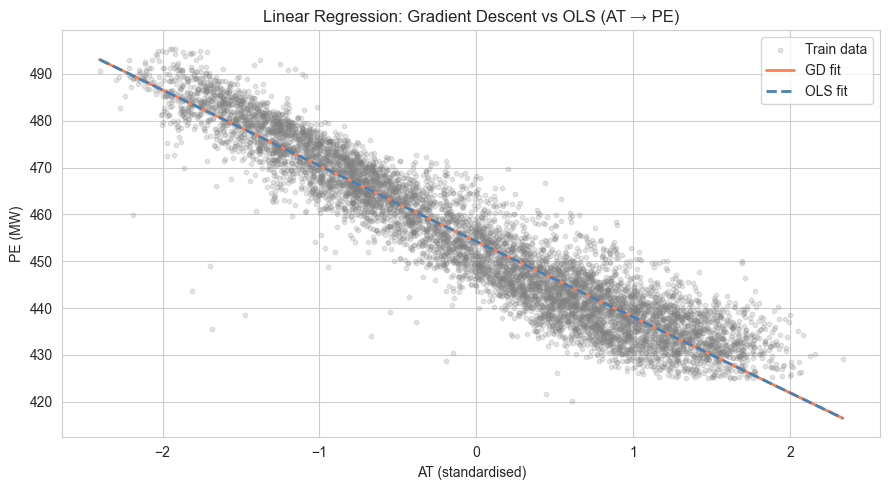

In [17]:
# OLS reference
ols = LinearRegression(solver="ols")
ols.fit(X_tr_s, y_tr)

print(f"OLS  slope={ols.coef_[0]:.4f}  intercept={ols.intercept_:.4f}")
print()
print(f"GD  Train R² = {1 - mse_loss(w_gd)/np.var(y_tr):.4f}  |  OLS Train R² = {ols.score(X_tr_s, y_tr):.4f}")

# Scatter + both regression lines
x_line = np.linspace(X_tr_s.min(), X_tr_s.max(), 200)
y_gd   = w_gd[0] * x_line + w_gd[1]
y_ols  = ols.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(9, 5))
plt.scatter(X_tr_s, y_tr, alpha=0.2, s=10, color="gray", label="Train data")
plt.plot(x_line, y_gd,  color="coral",     linewidth=2, label="GD fit")
plt.plot(x_line, y_ols, color="steelblue", linewidth=2, linestyle="--", label="OLS fit")
plt.title("Linear Regression: Gradient Descent vs OLS (AT → PE)")
plt.xlabel("AT (standardised)")
plt.ylabel("PE (MW)")
plt.legend()
plt.tight_layout()
plt.show()

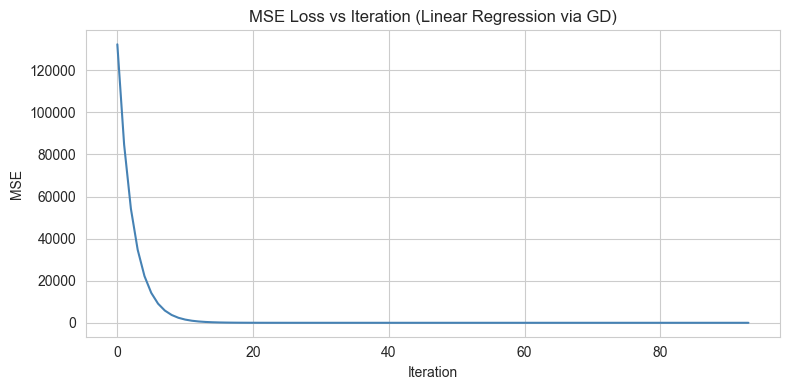

In [18]:
# Convergence of GD on regression task
plt.figure(figsize=(8, 4))
plt.plot(loss_hist_lr, color="steelblue")
plt.title("MSE Loss vs Iteration (Linear Regression via GD)")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

## Interpretation and Conclusions

### Algorithm Architecture: Strengths and Weaknesses

Gradient descent is a first-order iterative optimisation algorithm: at each step it moves the current parameter in the direction opposite to the gradient, scaled by the learning rate. Its primary strength is scalability — the update rule requires only a single gradient evaluation per step and extends trivially to high-dimensional parameter spaces where a closed-form solution either does not exist or requires inverting a matrix that is too large to store. The algorithm is also general: it can minimise any differentiable loss, not just quadratic objectives.

The central weaknesses are sensitivity to the learning rate and dependence on initialisation for non-convex problems. Both are demonstrated concretely in this notebook. For a convex problem (the MSE linear regression loss), these issues disappear because every local minimum is also the global minimum.

### Why It Worked on Each Task

**1-D function minimisation.** Starting at $x_0 = 3.0$, the algorithm converges to the deeper minimum near $x \approx 2.879$ with $f(x^*) = -15.234$. The trajectory plot shows smooth descent after a brief plateau near $x = 3$. Notably, the shallower local minimum near $x \approx 0.4$ is never visited — gradient descent is greedy and the initial gradient at $x_0 = 3.0$ points toward the deeper basin. A different starting point would likely yield the other minimum, illustrating that the solution found depends entirely on initialisation.

**Learning rate comparison.** The convergence plot for different learning rates shows that $\eta = 0.001$ makes slow, steady progress and has not fully converged by iteration 500. $\eta = 0.01$ converges cleanly within roughly 200 iterations. $\eta = 0.05$ reaches a similar level but shows mild oscillations in early iterations. $\eta = 0.1$ is near the stability limit for this function and produces visible oscillation before settling.

**2-D elliptical bowl.** The contour plot reveals that the loss surface is elongated along the $w_1$ axis (coefficient 5 vs coefficient 1 for $w_0$), so the gradient in the $w_1$ direction is five times steeper. This causes the characteristic zig-zag path visible in the contour plot: the algorithm overshoots in the steep direction before correcting. Despite this, convergence is reached at the origin ($L(w^*) \approx 0$) within 100 iterations at $\eta = 0.1$.

**Linear regression vs OLS.** Gradient descent finds slope $= -16.1688$ and intercept $= 454.2477$; the closed-form OLS solution is virtually identical. Because the MSE loss is strictly convex, the gradient is guaranteed to reach the global minimum regardless of initialisation, and the two methods agree to four decimal places. The convergence plot shows MSE falling steeply in early iterations and flattening as the solution is approached — consistent with the quadratic loss geometry. The practical takeaway is that OLS is preferable when the dataset is small enough to invert $X^\top X$ exactly; gradient descent becomes necessary when $n$ or $d$ is too large for matrix inversion to be tractable.